In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize
import corner
import emcee
import pandas as pd
import seaborn as sns
import multiprocessing
import cmdstanpy
#cmdstanpy.install_cmdstan(overwrite=True)
from cmdstanpy import CmdStanModel

import jax.numpy as jnp
from jax import jit, vmap, grad, jacfwd, hessian
import jax.random

from analysis import *

C:\Users\gugli\AppData\Local\Temp\ipykernel_13476\1855662253.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_old = pd.read_csv(


          m        m-        m+         r        r-        r+
0  0.327363  0.019070  0.019070  0.750996  0.011209  0.011209
1  0.387751  0.012713  0.012713  0.784623  0.011209  0.011209
2  0.632479  0.050853  0.050853  0.694952  0.022418  0.022418
3  0.692866  0.022248  0.022248  0.919130  0.011209  0.011209
4  1.039299  0.031783  0.031783  1.042428  0.011209  0.011209
[0.0112089  0.0112089  0.0224178  0.0112089  0.0112089  0.0448356
 0.0112089  0.0784623  0.0112089  0.0112089  0.0560445  0.0560445
 0.0336267  0.0560445  0.0784623  0.0560445  0.0448356  0.0896712
 0.0224178  0.0224178  0.112089   0.0560445  0.0224178  0.08406675
 0.0448356  0.05044005 0.0560445  0.0560445  0.0448356  0.0896712
 0.0560445  0.0672534  0.06164895 0.0784623  0.14571571 0.0448356
 0.0672534  0.05044005 0.0560445  0.0336267  0.02802225 0.112089
 0.0448356  0.0896712  0.11769345 0.0784623  0.1008801  0.0448356
 0.0672534  0.0672534  0.1008801  0.1345068  0.05044005 0.03923115
 0.112089   0.0784623  0.0448356 

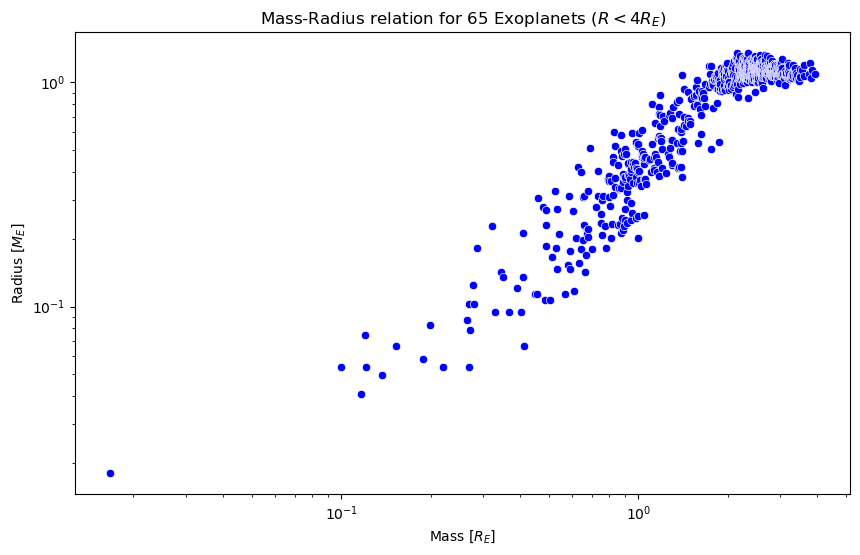

In [2]:
# Load and process the dataset
data_old = pd.read_csv(
    "DACE_Exo.csv", 
    delimiter=";", 
    dayfirst=True, 
    parse_dates=["last_updated"]
)

# Convert 'last_updated' to datetime with the specific format
data_old["last_updated"] = pd.to_datetime(data_old["last_updated"], format="%d.%m.%y", errors="coerce")

# Select relevant columns
data_new = data_old[[
    "planet_mass", "planet_mass_lower", "planet_mass_upper",
    "planet_radius", "planet_radius_lower", "planet_radius_upper",
    "discovery_year", "last_updated"
]]

# Drop rows with missing values
df = data_new.dropna()

# Ensure numeric conversion for relevant columns
cols_to_convert = ['planet_mass', 'planet_mass_lower', 'planet_mass_upper',
                   'planet_radius', 'planet_radius_lower', 'planet_radius_upper']
df.loc[:, cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# Drop rows with invalid (NaN) numeric data
df = df.dropna(subset=cols_to_convert)

# Convert 'last_updated' to Unix timestamps and ensure 'ts' is an integer
df['ts'] = (df['last_updated'].astype('int64') // 10**9).astype('int64')

# Rename columns
df.rename(columns={
    'planet_radius': 'r', 'planet_radius_upper': 'r+', 'planet_radius_lower': 'r-',
    'planet_mass': 'm', 'planet_mass_upper': 'm+', 'planet_mass_lower': 'm-'
}, inplace=True)

# Drop planets released after the paper came out
df = df.drop(df[(df['ts'] >= 1688252923) & (df['discovery_year'] == 2023)].index)

# Drop unwanted columns
df = df.drop(['ts', 'discovery_year', 'last_updated'], axis=1)

# Convert to Earth Masses and Radii
df['m'], df['m-'], df['m+'] = df['m'] * 317.8284, df['m-'] * 317.8284, df['m+'] * 317.8284
df['r'], df['r-'], df['r+'] = df['r'] * 11.2089, df['r-'] * 11.2089, df['r+'] * 11.2089

# Sort by mass
df = df.sort_values('m').reset_index(drop=True)

df = df.astype(float)

# Display processed data
print(df.head())

radius, mass, m_up, m_low, r_up, r_low = jnp.array(df['m']), jnp.array(df['r']), jnp.array(df['m+']), jnp.array(df['m-']), jnp.array(df['r+']), jnp.array(df['r-'])
#mass, radius, r_up, r_low, m_up, m_low = np.array(df['m']), np.array(df['r']), np.array(df['m+']), np.array(df['m-']), np.array(df['r+']), np.array(df['r-'])
m_err=jnp.concatenate((jnp.atleast_2d(m_low),jnp.atleast_2d(m_up)))
r_err=jnp.concatenate((jnp.atleast_2d(r_low),jnp.atleast_2d(r_up)))
sigma_mass=(r_up+r_low)/2
sigma_radius=(m_up+m_low)/2
print(sigma_mass, sigma_radius)

sigma_radius = sigma_radius / radius / np.log(10.0)
sigma_mass = sigma_mass / mass / np.log(10.0)
mass = jnp.log10(mass)
radius = jnp.log10(radius)

print(np.log(10))

# Plot the second column (x-axis) against the third column (y-axis)
plt.figure(figsize=(10, 6))

sns.scatterplot(x=radius, y=mass, marker='o', color='b')
plt.xlabel(r'Mass [$R_E$]')  # Add appropriate label for the second column
plt.ylabel(r'Radius [$M_E$]')   # Add appropriate label for the third column
plt.title(r'Mass-Radius relation for 65 Exoplanets ($R < 4R_E$)')

plt.xscale('log')
plt.yscale('log')

plt.show()

In [3]:
def plot_data_set(x, y, x_err=None, y_err=None):
    """Plot linear data set and format the plot."""
    fig, ax = plt.subplots(1, 1)
    if x_err is not None:
        ax.errorbar(x, y, x_err, y_err, fmt=".", label="Data")
    else:
        ax.errorbar(x, y, y_err, fmt=".", label="Data")
    ax.set_xlabel(r'Radius [$R_E$]')
    ax.set_ylabel(r'Mass [$M_E$]')
    ax.set_title(r'Mass-Radius relation for 65 Exoplanets ($R < 4R_E$)')
    #plt.xscale('log')
    #plt.yscale('log')
    return fig, ax

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Mass-Radius relation for 65 Exoplanets ($R < 4R_E$)'}, xlabel='Radius [$R_E$]', ylabel='Mass [$M_E$]'>)

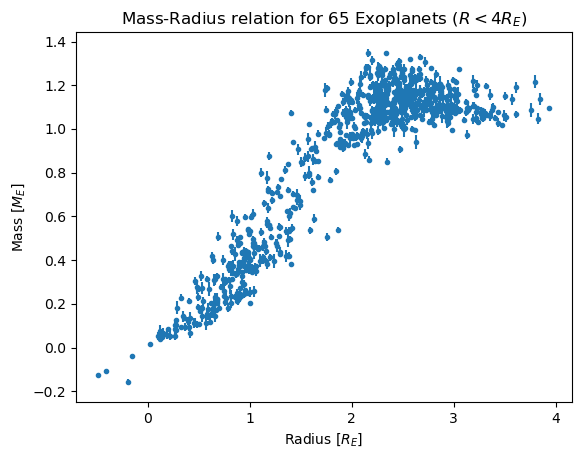

In [4]:
plot_data_set(radius, mass, None,  sigma_mass)

In [5]:
def pearson_r(x, y, axis=0):
    """Compute the Pearson correlation coefficient."""
    x_ = x - np.mean(x, axis=axis, keepdims=True)
    y_ = y - np.mean(y, axis=axis, keepdims=True)

    r = np.sum(x_*y_, axis=axis) / (np.sqrt(np.sum(x_**2, axis=axis))*np.sqrt(np.sum(y_**2, axis=axis)))
    return r
    
#Correlation Coefficient--Bivariate Normal Distribution, r is our best guess of what rho is, based on the sample we have.
#In statistical terms, r is an estimator for the true parameter rho. n number of pairs (x, y).
def pearson_r_pdf(r, n, rho): 
    """Compute the PDF of the Pearson correlation coefficient."""
    # https://mathworld.wolfram.com/CorrelationCoefficientBivariateNormalDistribution.html
    hypergeom = scipy.special.hyp2f1(0.5, 0.5, (2*n-1)/2, (rho*r+1)/2)
    Gamma = scipy.special.gamma
    return (
        (n-2)*Gamma(n-1)*(1-rho**2)**((n-1)/2)*(1-r**2)**((n-4)/2) 
        / (np.sqrt(2*np.pi)*Gamma(n-0.5)*(1-rho*r)**(n-3/2))
        * hypergeom
    )
def bootstrap(data, statistic, n_trial):
    n_data = data.shape[1]
    s = []
    for i in range(n_trial):
        idx = np.random.choice(n_data, size=n_data, replace=True)
        data_resampled = data[:, idx]
        s.append(statistic(data_resampled))
    
    return np.array(s)

In [6]:
def correlation(data):
    radius, mass = data
    r = np.corrcoef(radius, mass)[0, 1]
    return r

radius = np.array(radius)
mass = np.array(mass)
data_col = np.column_stack((radius, mass)).T
print(data_col)

correlation_samples = bootstrap(
    data_col,
    statistic=lambda data: correlation(
        data),
    n_trial=1000
)

[[-0.48497006 -0.41144747 -0.1989542  ...  3.8291426   3.8465848
   3.9372404 ]
 [-0.12436221 -0.10533895 -0.15804532 ...  1.0465121   1.1359227
   1.094886  ]]


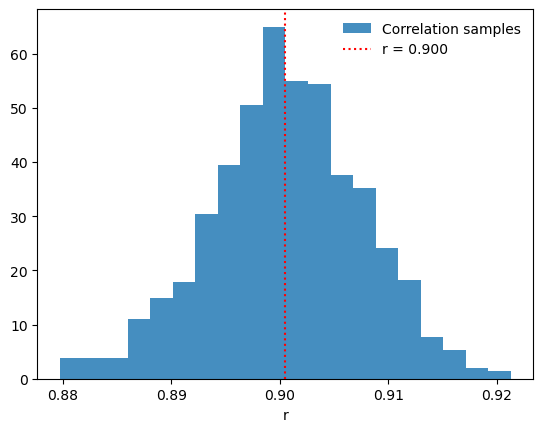

In [7]:
#print(correlation_samples)
n_trial = 65
n = n_trial
rho = np.corrcoef(radius, mass)[0, 1]

x = np.linspace(0.3, 0.9, 100)
plt.hist(correlation_samples[:], bins=20, density=True, alpha=0.83, label="Correlation samples")
#plt.plot(x, pearson_r_pdf(r=x, n=n, rho=rho), color="green", label=r"PDF $p(r|\rho, n)$")
plt.axvline(rho, ls=":", c="red", label=f"r = {rho:.3f}")
plt.legend(frameon=False)
plt.xlabel("r");

# Points are somewhat spread out but still show a general upward trend.

In [8]:
def PCA(data):
    # Remove the mean
    data_mean = data.mean(axis=1)[:, None]
    X = data - data_mean
    # Get covariance and its eigenvectors
    cov_X = np.cov(X)
    l, E = np.linalg.eigh(cov_X)

    # Sort by the eigenvalues
    sort_idx = np.argsort(l)[::-1]
    l = l[sort_idx]
    E = E[:,sort_idx]

    def project_onto_pc(d):
        if d.ndim == 1:
            d = d[:, np.newaxis]
        return E.T @ (d - data_mean)
    
    def reconstruct_from_pc(c):
        if c.ndim == 1:
            c = c[:, np.newaxis]
        return E[:, :c.shape[0]] @ c + data_mean

    return l, E, project_onto_pc, reconstruct_from_pc

l, E, project_onto_pc, reconstruct_from_pc = PCA(data_col)

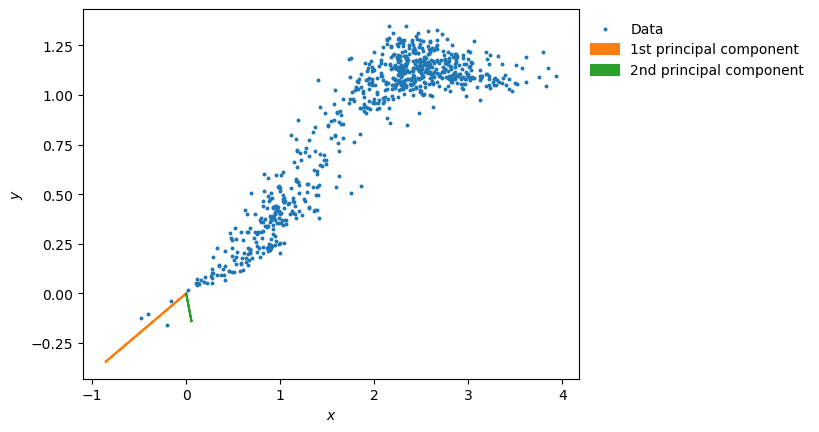

In [9]:
plt.scatter(*data_col, s=3.3, alpha=1.0, label="Data")
plt.arrow(0, 0, *(np.sqrt(l[0])*E[:, 0]), lw=1.5, color="C1", label="1st principal component")
plt.arrow(0, 0, *(np.sqrt(l[1])*E[:, 1]), lw=1.5, color="C2", label="2nd principal component")
#plt.gca().set_aspect('equal')
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1));

In [10]:
def model(theta, r):
    """
    A piecewise function with two non-smooth transition points between three power laws.

    Parameters:
        theta: Tuple of parameters (a1, b1, b2, b3, rc1, rc2)
               a1: Amplitude of the first power law
               b1: Exponent of the first power law
               b2: Exponent of the second power law
               b3: Exponent of the third power law
               rc1: First transition radius
               rc2: Second transition radius
        r: Radius values (array or scalar)

    Returns:
        Array or scalar representing the function value at each radius.
    """
    a1, b1, b2, b3, r1, r2 = theta

    # Small positive value to prevent invalid operations
    epsilon = 1e-7

    # Ensure r is positive
    r_safe = jnp.maximum(r, epsilon)


    # Define the three power laws
    f1 = a1 + b1 * r_safe
    f2 = b2 * (r_safe - r1) + b1 * r1 + a1
    f3 = b3 * (r_safe - r2) + b2 * (r2 - r1) + b1 * r1 + a1

    # Combine using np.where
    return jnp.where(r_safe <= r1, f1, jnp.where(r_safe <= r2, f2, f3))

In [11]:
def propagate_mass_error(theta, radius, sigma_radius, mass):
    """
    Propagate the error in radius (r) to the mass (m) using the provided piecewise model.

    Parameters:
        theta: Tuple of parameters (a1, b1, b2, b3, r1, r2)
               a1: Amplitude of the first power law
               b1: Exponent of the first power law
               b2: Exponent of the second power law
               b3: Exponent of the third power law
               r1: First transition radius
               r2: Second transition radius
        r: Radius values (array or scalar)
        sigma_r: Uncertainty in radius (array or scalar, same shape as r)
        mass: Mass values (array or scalar, same shape as r)

    Returns:
        sigma_mass: Propagated uncertainty in mass (same shape as r)
    """
    a1, b1, b2, b3, r1, r2 = theta

    # Small positive value to prevent invalid operations
    epsilon = 1e-7
    r_safe = jnp.maximum(radius, epsilon)

    # Define the three power 

    # Combine derivatives based on the radius range
    err = jnp.where(r_safe <= r1, b1, jnp.where(r_safe <= r2, b2, b3))

    # Propagate the error in radius to the function
    sigma_f = jnp.abs(err) * sigma_radius

    # Compute the propagated error on mass
    # Assuming mass = f(r) (simplified relation for propagation purposes)
    sigma_mass = sigma_f  # If mass is directly proportional to f(r)

    return sigma_mass
theta = [0.2,0.3,0.5,0.7,5.0,100]
print(model(theta, 10))
print(propagate_mass_error(theta,10,0.1,0.45839090779846564))

4.2
0.05


In [1]:
def build_likelihood():
    # Sample new data from the likelihood d -> m
    def predict(theta, radius, sigma_mass, sigma_radius, mass):
        mi = model(theta, radius)  # Compute model prediction
        a1, b1, b2, b3, r1, r2 = theta
        err_tot = 1*jnp.sqrt(sigma_mass**2 + (propagate_mass_error(theta, radius, sigma_radius, mass))**2)
        err_tot = jnp.maximum(err_tot, 1e-8)  # Prevent division by zero
        return mi + err_tot * jax.random.normal(jax.random.PRNGKey(0), shape=mi.shape)  # Sample from Gaussian distribution

    # Evaluate the log-likelihood HERE
    def log_likelihood(mass, theta, radius, sigma_mass, sigma_radius):
        mi = model(theta, radius)  # Model prediction
        #n = len(mass)
        a1, b1, b2, b3, r1, r2 = theta
        err_tot = 1*jnp.sqrt(sigma_mass**2 + (propagate_mass_error(theta, radius, sigma_radius, mass))**2)
        err_tot = jnp.maximum(err_tot, 1e-8)

        # Calculate the log-likelihood
        log_likelihood_value = (
            -0.5 * jnp.sum((mass - mi)**2 / err_tot**2)    # Exponent part
            -0.5 * jnp.sum(jnp.log(2 * jnp.pi * err_tot**2))  # Normalization part
        )
        
        return log_likelihood_value
    
    return predict, log_likelihood

In [2]:
def build_prior():
    low_a1, high_a1 = -0.17, 0.17
    low_b1, high_b1 = 0.15, 0.25
    low_b2, high_b2 = 0.1, 1.2
    low_b3, high_b3 = -0.55, 1.0
    low_r1, high_r1 = 0,1
    low_r2, high_r2 = 2,3
    
    def sample_from_prior(n):
        key = jax.random.PRNGKey(0)  # Set a seed for reproducibility

        # Split the key for reproducibility
        key_a1, key_b1, key_b2, key_b3, key_r1, key_r2 = jax.random.split(key, 6)

        # Draw samples for each parameter
        a1 = jax.random.uniform(key_a1, shape=(n,), minval=low_a1, maxval=high_a1)
        b1 = jax.random.uniform(key_b1, shape=(n,), minval=low_b1, maxval=high_b1)
        b2 = jax.random.uniform(key_b2, shape=(n,), minval=low_b2, maxval=high_b2)
        b3 = jax.random.uniform(key_b3, shape=(n,), minval=low_b3, maxval=high_b3)
        r1 = jax.random.uniform(key_r1, shape=(n,), minval=low_r1, maxval=high_r1)
        r2 = jax.random.uniform(key_r2, shape=(n,), minval=low_r2, maxval=high_r2)
        return jnp.stack((a1, b1, b2, b3, r1, r2)).T

    def log_prior(theta):
        a1, b1, b2, b3, r1, r2 = theta
        
        # Check if any parameter is out of bounds
        valid = (a1 >= low_a1) & (a1 <= high_a1) & \
                (b1 >= low_b1) & (b1 <= high_b1) & \
                (b2 >= low_b2) & (b2 <= high_b2) & \
                (b3 >= low_b3) & (b3 <= high_b3) & \
                (r1 >= low_r1) & (r1 <= high_r1) & \
                (r2 >= low_r2) & (r2 <= high_r2)
        
        # Use jax.lax.cond to handle the valid/invalid case
        log_prior_value = jax.lax.cond(
            valid, 
            lambda _: 0.0,  # Return 0.0 if all parameters are valid
            lambda _: -jnp.inf,  # Return -inf if any parameter is out of bounds
            theta
        )
        
        # Compute the normalization constant for each uniform prior
        norm_a1 = 1 / (high_a1 - low_a1)
        norm_b1 = 1 / (high_b1 - low_b1)
        norm_b2 = 1 / (high_b2 - low_b2)
        norm_b3 = 1 / (high_b3 - low_b3)
        norm_r1 = 1 / (high_r1 - low_r1)
        norm_r2 = 1 / (high_r2 - low_r2)
        
        # The log prior is the sum of the logs of the individual uniform priors
        log_prior_value += jnp.log(norm_a1) + jnp.log(norm_b1) + jnp.log(norm_b2) + \
                           jnp.log(norm_b3) + jnp.log(norm_r1) + jnp.log(norm_r2)
        
        return log_prior_value

    return sample_from_prior, log_prior

(20, 6)


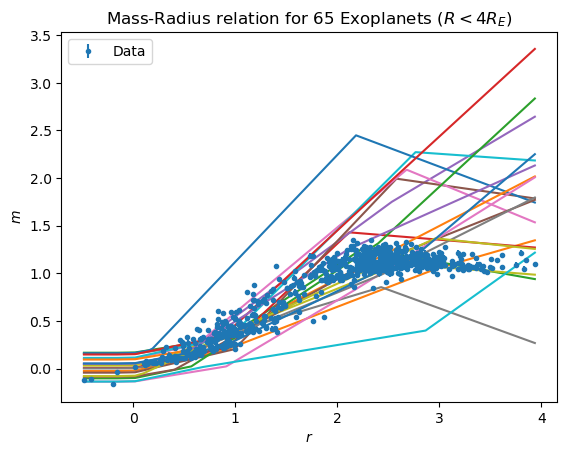

In [47]:
plot_data_set(radius,mass,sigma_mass)


sample_from_prior, log_prior = build_prior()

#print(sample_from_prior(n=20))

## Reproducibility
np.random.seed(42)
prior_parameters = sample_from_prior(n=20)
prior_model_predictive = np.array( [model(parameters, radius) for parameters in prior_parameters] )
print(prior_parameters.shape)
plt.plot(radius, prior_model_predictive[0])
plt.xlabel("$r$")
plt.ylabel("$m$")
plt.legend(loc="upper left")



plt.plot(radius , prior_model_predictive[1])
plt.plot(radius , prior_model_predictive[2])
for i in range(3,20):
    plt.plot(radius , prior_model_predictive[i])

In [48]:
# Since we have a Gaussian likelihood, we can add Gaussian noise with the 
# correct variance to our prior model predictions
#b_samples = prior_parameters[:,1] # Shape (20)
#print(b_samples)


n_rows = len(prior_parameters[:,0])
n_cols = len(radius)
err_tot = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    theta = [prior_parameters[i,0], prior_parameters[i,1],prior_parameters[i,2], prior_parameters[i,3],prior_parameters[i,4], prior_parameters[i,5]]
    for j in range(n_cols):
        err_tot[i,j] = np.sqrt(sigma_mass[j]**2 + (propagate_mass_error(theta, radius[j], sigma_radius[j], prior_model_predictive[i,j]))**2)
#err_tot = np.sqrt(sigma_mass**2 + (prior_model_predictive*b_samples*sigma_radius/radius)**2)
# Check the shape of the result

#print(err_tot.shape)  # Should output (20, 65)  (prior_model_predictive[i,j]*b_samples[i]*sigma_radius[j]/radius[j])**2

prior_predictive = ( prior_model_predictive + err_tot*np.random.normal(size=prior_model_predictive.shape) ) ## MEAN

print(prior_model_predictive.shape)

(20, 760)


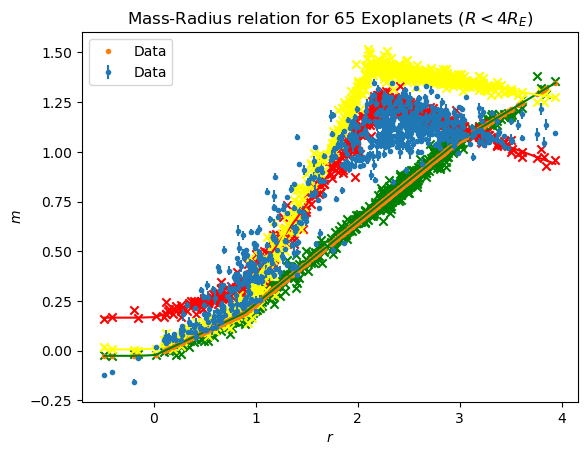

In [49]:
plot_data_set(radius, mass, sigma_mass)


plt.plot(radius, prior_model_predictive[0], marker=".", linestyle="none", label="Data")
plt.xlabel("$r$")
plt.ylabel("$m$")
plt.legend(loc="upper left")

color = ["green", "red", "yellow" ]
for i in range(3):
    plt.plot(radius , prior_model_predictive[i], color=color[i])

#############
for i in range(3):
    plt.scatter(radius, prior_predictive[i], marker='x', color=color[i])

In [1]:
# FIT
predict, log_likelihood = build_likelihood()


def log_posterior_probability(theta, radius, sigma_mass, mass, sigma_radius):
    a1, b1, b2, b3, r1, r2 = theta
    return ( log_likelihood(mass, theta, radius, sigma_mass,sigma_radius) + log_prior(theta) )

NameError: name 'build_likelihood' is not defined

In [51]:
theta = (1,1,1,1,1,1)
a = np.array([1,1]) #len(n)
%timeit log_posterior_probability(theta, a,a,a,a)

57.3 ms ± 2.63 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [52]:
"""
low_a1, high_a1 = -0.4, 0.3
    low_b1, high_b1 = 0.1, 0.5
    low_b2, high_b2 = -0.1, 1.3
    low_b3, high_b3 = -0.55, 1.0
    low_r1, high_r1 = 0,1
    low_r2, high_r2 = 2,3
    
"""

# The scipy minimizer finds the minimum, so we need to take the 
# negative of the posterior. The scipy minimizer also passes an array 
# with the parameters, this wrapper splits this array into m and b.
def negative_log_posterior(theta, radius, sigma_mass, mass, sigma_radius):
    a1, b1, b2, b3, r1, r2 = theta
    return -log_posterior_probability(theta, radius, sigma_mass, mass, sigma_radius)
    
MAP_result = scipy.optimize.minimize(
    fun=lambda theta: -log_posterior_probability(theta=theta, radius=radius,
    sigma_mass=sigma_mass, mass=mass, sigma_radius=sigma_radius),
    #x0=(2.0, 2., 2., 2, 2, 10.)
    x0=(0.1, 0.2, 0.5, -0.1, 0.3, 2.55)
    ) # theta is the variable in function of which we want minimize
a1_MAP, b1_MAP, b2_MAP, b3_MAP, r1_MAP, r2_MAP = MAP_result.x
#m_true = 1.3
#b_true = -0.2
print("MAP results")
print(f"a1_MAP = {a1_MAP:.3f}, b1_MAP = {b1_MAP:.3f}, b2_MAP = {b2_MAP:.3f}, b3_MAP = {b3_MAP:.3f}, r1_MAP = {r1_MAP:.3f}, r2_MAP = {r2_MAP:.3f}")
#print(f"m_true = {m_true:.3f}, b_true = {b_true:.3f}")

C:\ProgramData\anaconda3\Lib\site-packages\scipy\optimize\_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0


MAP results
a1_MAP = 0.072, b1_MAP = 0.207, b2_MAP = 0.493, b3_MAP = -0.128, r1_MAP = 0.207, r2_MAP = 2.550


[[-0.02234321  0.23518355  1.1892315   0.3860835   0.9326004   2.384004  ]
 [ 0.04108498  0.15034896  1.155345   -0.01273354  0.68533576  2.760233  ]
 [-0.16762236  0.22220373  0.42139742  0.1477931   0.8235494   2.271617  ]
 [ 0.11385033  0.19226132  0.31338507 -0.22181168  0.8720517   2.9007902 ]
 [ 0.1387476   0.22285536  1.1637627   0.06276084  0.6662258   2.500318  ]]


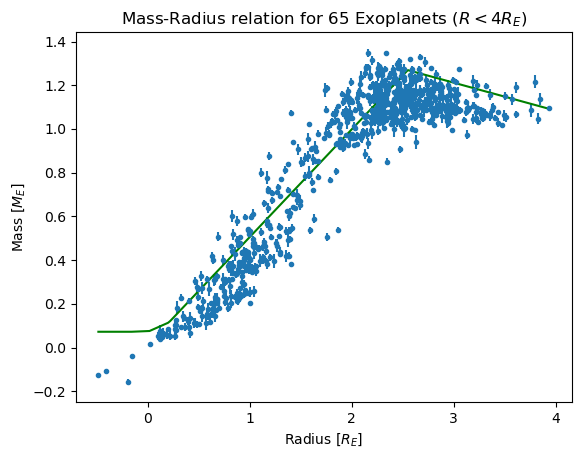

In [53]:
plot_data_set(radius, mass, sigma_mass)


plt.plot(radius, model((a1_MAP, b1_MAP, b2_MAP, b3_MAP, r1_MAP, r2_MAP), radius), color = "green")
#plt.plot(x, m_true*x + b_true)
#theta_init = np.array([0,0,0,0,1,2]) * np.random.normal(size=(3, 6)) # different weights
#print(theta_init)

init = sample_from_prior(5)
print(init)

In [54]:
from emcee.moves import StretchMove

# emcee passes an array of values for the sampled parameters
# This wrapper just splits the array theta into m and b

# emcee requires some extra settings to run
n_param = 6       # Number of parameter we are sampling
n_walker = 15     # Number of walkers. This just needs to be 
                  # larger than 2*n_param + 1!
n_step = 5000     # How many steps each walker will take. The number
                  # of samples will be n_walker*n_step

#red_blue_move = emcee.moves.RedBlueMove(nsplits=2, randomize_split=True, live_dangerously=True)

# The starting point for each walker


#with multiprocessing.Pool() as pool:
    # Define theta_init and the sampler
#    theta_init = np.array([a1_MAP, b1_MAP, a2_MAP, b2_MAP, rc_MAP]) + 0.3 * np.random.normal(size=(n_walker, n_param))
#    sampler = emcee.EnsembleSampler(
#        nwalkers=n_walker, ndim=n_param, log_prob_fn=log_posterior_probability, args=(radius, sigma_mass, mass), pool=pool, moves=(emcee.moves.RedBlueMove(nsplits=2.5, randomize_split=True, live_dangerously=True))
#    )
    # Run MCMC, emcee.moves.RedBlueMove(nsplits=2, randomize_split=True, live_dangerously=False) , emcee.moves.StretchMove(a=2.5)
#    %time state = sampler.run_mcmc(theta_init, nsteps=n_step)

#theta_init = sample_from_prior(n_walker) 
theta_init = np.array([a1_MAP, b1_MAP, b2_MAP, b3_MAP, r1_MAP, r2_MAP]) + np.array([0.1,0.1,0.1,0.1,0.1,0.1])* np.random.normal(size=(n_walker, n_param)) # different weights
sampler = emcee.EnsembleSampler(nwalkers=n_walker, ndim=n_param, log_prob_fn=log_posterior_probability, args=(radius, sigma_mass, mass, sigma_radius), moves=[emcee.moves.StretchMove(a=2.1)] )
%time state = sampler.run_mcmc(theta_init, nsteps=n_step)

acceptance_rate = sampler.acceptance_fraction

# Print the acceptance rate
print(f"Acceptance rate per walker: {acceptance_rate}")
print(f"Mean acceptance rate: {acceptance_rate.mean()}")

C:\Users\gugli\AppData\Roaming\Python\Python311\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


CPU times: total: 13min 58s
Wall time: 5h 23min 5s
Acceptance rate per walker: [0.3624 0.3606 0.3494 0.3696 0.375  0.3812 0.3998 0.4014 0.3892 0.3558
 0.399  0.3954 0.3912 0.3696 0.3564]
Mean acceptance rate: 0.37706666666666666


In [ ]:
# The samples will be correlated, this checks how correlated they are
# We will discuss this once we come to MCMC methods
print("Auto-correlation time: ")
for name, value in zip(["a1", "b1", "b2", "b3", "r1", "r2"], sampler.get_autocorr_time()):
    print(f"{name} = {value:.1f}")
# We need to discard the beginning of the chain (a few auto-correlation times)
# to get rid of the initial conditions
chain = sampler.get_chain(discard=500, thin=100, flat=True)

Auto-correlation time: 


In [34]:
print(chain.shape)
chain_per_walker = sampler.get_chain(discard=300, thin=10, flat=False)
param_names = ["a1", "b1", "b2", "b3", "r1", "r2"]

# Plot the tracer of the chain, this time for all the walkers
fig, ax = plt.subplots(len(param_names), 1, sharex=True)
plt.subplots_adjust(hspace=0)

for i, name in enumerate(param_names):
    for j in range(n_walker):
        ax[i].plot(chain_per_walker[:, j, i], lw=0.5, alpha=0.7, color=f"C{j}")
    ax[i].set_ylabel(name)

ax[-1].set_xlabel("step");  #OTHER MINIMA

NameError: name 'chain' is not defined

In [ ]:
print("Posterior results (mean±std): ")
print(f"a1 = {np.mean(chain[:,0]):.3f}±{np.std(chain[:,0]):.3f}")
print(f"b1 = {np.mean(chain[:,1]):.3f}±{np.std(chain[:,1]):.3f}")
print(f"b2 = {np.mean(chain[:,2]):.3f}±{np.std(chain[:,2]):.3f}")
print(f"b3 = {np.mean(chain[:,3]):.3f}±{np.std(chain[:,3]):.3f}")
print(f"r1 = {np.mean(chain[:,4]):.3f}±{np.std(chain[:,4]):.3f}")
print(f"r2 = {np.mean(chain[:,5]):.3f}±{np.std(chain[:,5]):.3f}")


print(chain.shape)

In [ ]:
from scipy.stats import gaussian_kde

# Calculate the mode for each parameter in `chain`
modes = []
for i in range(chain.shape[1]):
    hist, bin_edges = np.histogram(chain[:, i], bins=40)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    max_bin_index = np.argmax(hist)
    mode_value = bin_centers[max_bin_index]
    modes.append(mode_value)

# Now calculate the 2D mode (highest density point) for the parameters

kde = gaussian_kde(chain.T)
mode_2d = chain[np.argmax(kde(chain.T)), :]
print(mode_2d)

a1_mode, b1_mode, b2_mode, b3_mode, r1_mode, r2_mode = mode_2d

fig = plt.figure()
fig = corner.corner(chain,
bins=40,
labels=["a1", "b1", "b2", "b3", "r1", "r2"],
color="green",
truths=[a1_mode, b1_mode, b2_mode, b3_mode, r1_mode, r2_mode],
truth_color="blue",
levels=1-np.exp(-0.5*np.array([1, 2])**2), # Credible contours corresponding
# to 1 and 2 sigma in 2D
quantiles=[0.025, 0.16, 0.84, 0.975],
fig=fig
);
fig.get_axes()[0].plot([], [], c="green", label="Samples from the posterior")
fig.get_axes()[0].plot([], [], c="blue", label="2d mode")
fig.get_axes()[0].legend(loc=2, bbox_to_anchor=(1, 1))




# Add vertical lines for the modes on the diagonal plots
axes = fig.get_axes()
#for i, mode_value in enumerate(modes):
    # The diagonal plots are located at positions [0, 3, 6, ...] in a corner plot with two parameters
    #axes[i * (chain.shape[1] + 1)].axvline(mode_value, color="red", linestyle="--", label="Mode")

# Add a legend for the mode line

#axes[0].legend(loc="upper right")

plt.show()

In [ ]:
# CHECK

# Previous plots: 
plot_data_set(radius, mass, sigma_mass)


plt.plot(radius, model((a1_MAP, b1_MAP, b2_MAP, b3_MAP, r1_MAP, r2_MAP), radius), color = "green")


# Choose a small subsample of the chain for plotting purposes
chain_samples = chain[np.random.choice(chain.shape[0], size=200)]
# Evaluate the model at the sample parameters
model_predictive = np.array( [model(sample, radius) for sample in chain_samples] )
model_quantiles = np.quantile( model_predictive, q=[0.025, 0.16, 0.84, 0.975], axis=0 )
print(model_predictive[0,:])
print(model_predictive.shape)
#print(model_quantiles)

plt.plot(radius, model_quantiles[0,:], "yellow")
plt.plot(radius, model_quantiles[1,:], color="grey")
plt.plot(radius, model_quantiles[2,:], color="black")
plt.plot(radius, model_quantiles[3,:], color="red")

plt.fill_between(radius, model_quantiles[0,:], model_quantiles[3,:],alpha=0.333, linewidth=0, color = "orange")
plt.fill_between(radius, model_quantiles[1,:], model_quantiles[2,:],alpha=0.9, linewidth=0, color = "orange")


# error on posterior not so big

In [ ]:
# Since we have a Gaussian likelihood, we can add Gaussian noise with the 
# correct variance to our prior model predictions
#b_samples = prior_parameters[:,1] # Shape (20)
#print(b_samples)


n_rows = len(chain_samples[:,0])
n_cols = len(radius)
err_tot = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    theta = [chain_samples[i,0], chain_samples[i,1],chain_samples[i,2],chain_samples[i,3],chain_samples[i,4], chain_samples[i,5]]
    for j in range(n_cols):
        err_tot[i,j] = np.sqrt(sigma_mass[j]**2 + (propagate_mass_error(theta, radius[j], sigma_radius[j], model_predictive[i,j]))**2)
#err_tot = np.sqrt(sigma_mass**2 + (prior_model_predictive*b_samples*sigma_radius/radius)**2)
# Check the shape of the result

#print(err_tot.shape)  # Should output (20, 65)  (prior_model_predictive[i,j]*b_samples[i]*sigma_radius[j]/radius[j])**2

posterior_predictive = ( model_predictive + err_tot*np.random.normal(size=model_predictive.shape) ) ## MEAN

print(model_predictive.shape)

In [ ]:
radius = np.array(radius)
"""
print(type(radius))
print(radius, np.shape(radius)) # 65
print(posterior_predictive, np.shape(posterior_predictive)) # (200, 65)
"""

fig, ax = plt.subplots(figsize=(33, 5.5))

# Create the violin plot
violin_parts = ax.violinplot(posterior_predictive, positions=radius, showmeans=False, showmedians=False, widths=0.1)

# Customize the appearance of the violins
for partname in ('cbars','cmins','cmaxes'):
    vp = violin_parts[partname]
    vp.set_edgecolor('gray')
    vp.set_linewidth(1.5)

# Change the colors of the violins
for pc in violin_parts['bodies']:
    pc.set_facecolor('skyblue')  # Change the color of the violins
    pc.set_edgecolor('black')  # Set the border color
    pc.set_alpha(0.3)  # Set transparency

# Add axis labels and a title
ax.set_xlabel(r'Radius [$R_E$]')
ax.set_ylabel(r'Mass [$M_E$]')
ax.set_title("Posterior Predictive Distribution", fontsize=14)

# Show gridlines
ax.grid(True)

# Add a legend or labels
ax.legend(['Samples from posterior'], loc='upper left')

# Previous plots: 
ax.errorbar(radius, mass, sigma_mass, fmt=".", label="Data")

plt.xscale('log')
plt.yscale('log')

# Show the plot
plt.savefig("violin.png")
plt.show()

In [ ]:
# 2 PIECES
# 2 PIECES
# 2 PIECES
# 2 PIECES
# 2 PIECES
# 2 PIECES
# 2 PIECES
# 2 PIECES
# 2 PIECES
# 2 PIECES

In [ ]:
def model2(theta, r):
    a1, b1, b2, r1 = theta  # Removed parameters for r2, b3, and a3

    # Small positive value to prevent invalid operations
    epsilon = 1e-7

    # Ensure r is positive
    r_safe = np.maximum(r, epsilon)


    # Define the two power laws
    f1 = a1 + b1 * r_safe
    f2 = b2 * (r_safe - r1) + b1 * r_safe + a1

    # Combine using np.where with a single non-smoothness point at r1
    f = np.where(r_safe <= r1, f1, f2)

    return f

In [ ]:
def propagate_mass_error2(theta, radius, sigma_radius, mass):

    a1, b1, b2, b3, r1 = theta

    # Small positive value to prevent invalid operations
    epsilon = 1e-7
    r_safe = np.maximum(radius, epsilon)

    # Combine derivatives based on the radius range
    err = np.where(r_safe <= r1, b1, b2)

    # Propagate the error in radius to the function
    sigma_f = np.abs(err) * sigma_radius

    # Compute the propagated error on mass
    # Assuming mass = f(r) (simplified relation for propagation purposes)
    sigma_mass = sigma_f  # If mass is directly proportional to f(r)

    return sigma_mass
#theta = [0.2,0.3,0.5,0.7,5.0]
#print(model(theta, 10))
#print(propagate_mass_error(theta,10,0.1,0.45839090779846564))

In [ ]:
def build_likelihood2():
    # Sample new data from the likelihood d -> m
    def predict(theta, radius, sigma_mass, sigma_radius, mass):
        mi = model(theta, radius)  # Compute model prediction
        a1, b1, b2, b3, r1 = theta
        err_tot = 1*np.sqrt(sigma_mass**2 + (propagate_mass_error2(theta, radius, sigma_radius, mass))**2)
        err_tot = np.maximum(err_tot, 1e-8)  # Prevent division by zero
        return np.random.normal(loc=mi, scale=err_tot)  # Sample from Gaussian distribution

    # Evaluate the log-likelihood HERE
    def log_likelihood(mass, theta, radius, sigma_mass, sigma_radius):
        mi = model(theta, radius)  # Model prediction
        n = len(mass)
        a1, b1, b2, b3, r1 = theta
        err_tot = 1*np.sqrt(sigma_mass**2 + (propagate_mass_error2(theta, radius, sigma_radius, mass))**2)
        err_tot = np.maximum(err_tot, 1e-8)  # Prevent division by zero

        # Calculate the log-likelihood
        log_likelihood_value = (
            -0.5 * np.sum((mass - mi)**2 / err_tot**2)    # Exponent part
            -0.5 * np.sum(np.log(2 * np.pi * err_tot**2))  # Normalization part
        )
        
        return log_likelihood_value
    
    return predict, log_likelihood

In [ ]:
def build_prior2():
    low_a1, high_a1 = 2.,3#0.5, 1.5
    low_b1, high_b1 = 1.,2.5#0.1, 1.0
    low_b2, high_b2 = 1.,2.5#0.1, 1.0
    low_b3, high_b3 = 2.5,5#-0.5, 1.0
    low_r1, high_r1 = 0.5,5#2.0, 8.0
    def sample_from_prior(n):
        a1 = np.random.uniform(low=low_a1, high=high_a1, size=(n,))
        b1 = np.random.uniform(low=low_b1, high=high_b1, size=(n,))
        b2 = np.random.uniform(low=low_b2, high=high_b2, size=(n,))
        b3 = np.random.uniform(low=low_b3, high=high_b3, size=(n,))
        r1 = np.random.uniform(low=low_r1, high=high_r1, size=(n,))
        return np.stack((a1, b1, b2, b3, r1)).T
    def log_prior(theta):
        a1, b1, b2, b3, r1, r2 = theta
        if (a1 < low_a1 or high_a1 < a1
        or b1 < low_b1 or high_b1 < b1
        or b2 < low_b2 or high_b2 < b2
        or b3 < low_b3 or high_b3 < b3
        or r1 < low_r1 or high_r1 < r1):
            return -np.inf
        # Compute the normalization constant for each uniform prior
        norm_a1 = 1 / (high_a1 - low_a1)
        norm_b1 = 1 / (high_b1 - low_b1)
        norm_b2 = 1 / (high_b2 - low_b2)
        norm_b3 = 1 / (high_b3 - low_b3)
        norm_r1 = 1 / (high_r1 - low_r1)
        
        # The log prior is the sum of the logs of the individual uniform priors
        log_prior_value = np.log(norm_a1) + np.log(norm_b1) + np.log(norm_b2) + \
                          np.log(norm_b3) + np.log(norm_r1)
        
        return log_prior_value
    return sample_from_prior, log_prior

In [ ]:
plot_data_set(radius,mass,sigma_mass)


sample_from_prior, log_prior = build_prior2()

#print(sample_from_prior(n=20))

## Reproducibility
np.random.seed(42)
prior_parameters = sample_from_prior(n=20)
prior_model_predictive = np.array( [model2(parameters, radius) for parameters in prior_parameters] )
print(prior_parameters.shape)
plt.plot(radius, prior_model_predictive[0])
plt.xlabel("$r$")
plt.ylabel("$m$")
plt.legend(loc="upper left")



plt.plot(radius , prior_model_predictive[1])
plt.plot(radius , prior_model_predictive[2])
for i in range(3,20):
    plt.plot(radius , prior_model_predictive[i])

In [ ]:
# Since we have a Gaussian likelihood, we can add Gaussian noise with the 
# correct variance to our prior model predictions
#b_samples = prior_parameters[:,1] # Shape (20)
#print(b_samples)


n_rows = len(prior_parameters[:,0])
n_cols = len(radius)
err_tot = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    theta = [prior_parameters[i,0], prior_parameters[i,1],prior_parameters[i,2], prior_parameters[i,3],prior_parameters[i,4], prior_parameters[i,5]]
    for j in range(n_cols):
        err_tot[i,j] = np.sqrt(sigma_mass[j]**2 + (propagate_mass_error2(theta, radius[j], sigma_radius[j], prior_model_predictive[i,j]))**2)
#err_tot = np.sqrt(sigma_mass**2 + (prior_model_predictive*b_samples*sigma_radius/radius)**2)
# Check the shape of the result

#print(err_tot.shape)  # Should output (20, 65)  (prior_model_predictive[i,j]*b_samples[i]*sigma_radius[j]/radius[j])**2

prior_predictive = ( prior_model_predictive + err_tot*np.random.normal(size=prior_model_predictive.shape) ) ## MEAN

print(prior_model_predictive.shape)

In [ ]:
plot_data_set(radius, mass, sigma_mass)


plt.plot(radius, prior_model_predictive[0], marker=".", linestyle="none", label="Data")
plt.xlabel("$r$")
plt.ylabel("$m$")
plt.legend(loc="upper left")

color = ["green", "red", "yellow" ]
for i in range(3):
    plt.plot(radius , prior_model_predictive[i], color=color[i])

#############
for i in range(3):
    plt.scatter(radius, prior_predictive[i], marker='x', color=color[i])

In [ ]:
# FIT
predict, log_likelihood2 = build_likelihood2()


def log_posterior_probability2(theta, radius, sigma_mass, mass, sigma_radius):
    a1, b1, b2, b3, r1 = theta
    return ( log_likelihood2(mass, theta, radius, sigma_mass, sigma_radius) + log_prior(theta) )

In [ ]:
theta = (1,1,1,1,1)
a = np.array([1,1]) #len(n)
%timeit log_posterior_probability(theta, a,a,a,a)

In [ ]:
# The scipy minimizer finds the minimum, so we need to take the 
# negative of the posterior. The scipy minimizer also passes an array 
# with the parameters, this wrapper splits this array into m and b.
def negative_log_posterior2(theta, radius, sigma_mass, mass, sigma_radius):
    a1, b1, b2, b3, r1 = theta
    return -log_posterior_probability2(theta, radius, sigma_mass, mass, sigma_radius)
    
MAP_result = scipy.optimize.minimize(
    fun=lambda theta: -log_posterior_probability2(theta=theta, radius=radius,
    sigma_mass=sigma_mass, mass=mass, sigma_radius=sigma_radius),
    x0=(1.0, 0.5, 0.5, 0.1, 5.3)
    ) # theta is the variable in function of which we want minimize
a1_MAP2, b1_MAP2, b2_MAP2, b3_MAP2, r1_MAP2 = MAP_result.x
#m_true = 1.3
#b_true = -0.2
print("MAP results")
print(f"a1_MAP = {a1_MAP:.3f}, b1_MAP = {b1_MAP:.3f}, b2_MAP = {b2_MAP:.3f}, b3_MAP = {b3_MAP:.3f}, r1_MAP = {r1_MAP:.3f}")
#print(f"m_true = {m_true:.3f}, b_true = {b_true:.3f}")


In [ ]:
plot_data_set(radius, mass, sigma_mass)


plt.plot(radius, model2((a1_MAP2, b1_MAP2, b2_MAP2, b3_MAP2, r1_MAP2), radius), color = "green")
#plt.plot(x, m_true*x + b_true)
#theta_init = np.array([0,0,0,0,1,2]) * np.random.normal(size=(3, n_param)) # different weights
#print(theta_init)

In [ ]:
from emcee.moves import StretchMove

# emcee passes an array of values for the sampled parameters
# This wrapper just splits the array theta into m and b

# emcee requires some extra settings to run
n_param = 5       # Number of parameter we are sampling
n_walker = 12     # Number of walkers. This just needs to be 
                  # larger than 2*n_param + 1!
n_step = 33000     # How many steps each walker will take. The number
                  # of samples will be n_walker*n_step

#red_blue_move = emcee.moves.RedBlueMove(nsplits=2, randomize_split=True, live_dangerously=True)

# The starting point for each walker


#with multiprocessing.Pool() as pool:
    # Define theta_init and the sampler
#    theta_init = np.array([a1_MAP, b1_MAP, a2_MAP, b2_MAP, rc_MAP]) + 0.3 * np.random.normal(size=(n_walker, n_param))
#    sampler = emcee.EnsembleSampler(
#        nwalkers=n_walker, ndim=n_param, log_prob_fn=log_posterior_probability, args=(radius, sigma_mass, mass), pool=pool, moves=(emcee.moves.RedBlueMove(nsplits=2.5, randomize_split=True, live_dangerously=True))
#    )
    # Run MCMC, emcee.moves.RedBlueMove(nsplits=2, randomize_split=True, live_dangerously=False) , emcee.moves.StretchMove(a=2.5)
#    %time state = sampler.run_mcmc(theta_init, nsteps=n_step)

theta_init = np.array([a1_MAP2, b1_MAP2, b2_MAP2, b3_MAP2, r1_MAP2]) + np.array([0.1,0.1,0.1,0.1,0.1])* np.random.normal(size=(n_walker, n_param)) # different weights
sampler = emcee.EnsembleSampler(nwalkers=n_walker, ndim=n_param, log_prob_fn=log_posterior_probability2, args=(radius, sigma_mass, mass, sigma_radius), moves=[emcee.moves.StretchMove(a=2.1)] )
%time state = sampler.run_mcmc(theta_init, nsteps=n_step)

acceptance_rate = sampler.acceptance_fraction

# Print the acceptance rate
print(f"Acceptance rate per walker: {acceptance_rate}")
print(f"Mean acceptance rate: {acceptance_rate.mean()}")

In [ ]:
# The samples will be correlated, this checks how correlated they are
# We will discuss this once we come to MCMC methods
print("Auto-correlation time: ")
for name, value in zip(["a1", "b1", "b2", "b3", "r1"], sampler.get_autocorr_time()):
    print(f"{name} = {value:.1f}")
# We need to discard the beginning of the chain (a few auto-correlation times)
# to get rid of the initial conditions
chain2 = sampler.get_chain(discard=500, thin=100, flat=True) #THIN

In [ ]:
print(chain2.shape)
chain_per_walker2 = sampler.get_chain(discard=300, thin=10, flat=False) #THIN
param_names = ["a1", "b1", "b2", "b3", "r1"]

# Plot the tracer of the chain, this time for all the walkers
fig, ax = plt.subplots(len(param_names), 1, sharex=True)
plt.subplots_adjust(hspace=0)

for i, name in enumerate(param_names):
    for j in range(n_walker):
        ax[i].plot(chain_per_walker2[:, j, i], lw=0.5, alpha=0.7, color=f"C{j}")
    ax[i].set_ylabel(name)

ax[-1].set_xlabel("step");  #OTHER MINIMA

In [ ]:
print("Posterior results (mean±std): ")
print(f"a1 = {np.mean(chain2[:,0]):.3f}±{np.std(chain2[:,0]):.3f}")
print(f"b1 = {np.mean(chain2[:,1]):.3f}±{np.std(chain2[:,1]):.3f}")
print(f"b2 = {np.mean(chain2[:,2]):.3f}±{np.std(chain2[:,2]):.3f}")
print(f"b3 = {np.mean(chain2[:,3]):.3f}±{np.std(chain2[:,3]):.3f}")
print(f"r1 = {np.mean(chain2[:,4]):.3f}±{np.std(chain2[:,4]):.3f}")


print(chain)

In [ ]:
from scipy.stats import gaussian_kde

# Calculate the mode for each parameter in `chain`
modes = []
for i in range(chain2.shape[1]):
    hist, bin_edges = np.histogram(chain2[:, i], bins=40)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    max_bin_index = np.argmax(hist)
    mode_value = bin_centers[max_bin_index]
    modes.append(mode_value)

# Now calculate the 2D mode (highest density point) for the parameters

kde = gaussian_kde(chain2.T)
mode_2d = chain2[np.argmax(kde(chain2.T)), :]
print(mode_2d)

a1_mode, b1_mode, b2_mode, b3_mode, r1_mode = mode_2d

fig = plt.figure()
fig = corner.corner(chain2,
bins=40,
labels=["a1", "b1", "b2", "b3", "r1"],
color="green",
truths=[a1_mode, b1_mode, b2_mode, b3_mode, r1_mode],
truth_color="blue",
levels=1-np.exp(-0.5*np.array([1, 2])**2), # Credible contours corresponding
# to 1 and 2 sigma in 2D
quantiles=[0.025, 0.16, 0.84, 0.975],
fig=fig
);
fig.get_axes()[0].plot([], [], c="green", label="Samples from the posterior")
fig.get_axes()[0].plot([], [], c="blue", label="2d mode")
fig.get_axes()[0].legend(loc=2, bbox_to_anchor=(1, 1))




# Add vertical lines for the modes on the diagonal plots
axes = fig.get_axes()
#for i, mode_value in enumerate(modes):
    # The diagonal plots are located at positions [0, 3, 6, ...] in a corner plot with two parameters
    #axes[i * (chain.shape[1] + 1)].axvline(mode_value, color="red", linestyle="--", label="Mode")

# Add a legend for the mode line

#axes[0].legend(loc="upper right")

plt.show()


In [ ]:
# CHECK

# Previous plots: 
plot_data_set(radius, mass, sigma_mass)


plt.plot(radius, model2((a1_MAP2, b1_MAP2, b2_MAP2, b3_MAP2, r1_MAP2), radius), color = "green")


# Choose a small subsample of the chain for plotting purposes
chain_samples2 = chain2[np.random.choice(chain.shape[0], size=200)]
# Evaluate the model at the sample parameters
model_predictive = np.array( [model2(sample, radius) for sample in chain_samples2] )
model_quantiles = np.quantile( model_predictive, q=[0.025, 0.16, 0.84, 0.975], axis=0 )
print(model_predictive[0,:])
print(model_predictive.shape)
#print(model_quantiles)

plt.plot(radius, model_quantiles[0,:], "yellow")
plt.plot(radius, model_quantiles[1,:], color="grey")
plt.plot(radius, model_quantiles[2,:], color="black")
plt.plot(radius, model_quantiles[3,:], color="red")

plt.fill_between(radius, model_quantiles[0,:], model_quantiles[3,:],alpha=0.333, linewidth=0, color = "orange")
plt.fill_between(radius, model_quantiles[1,:], model_quantiles[2,:],alpha=0.9, linewidth=0, color = "orange")


# error on posterior not so big

In [ ]:
# Since we have a Gaussian likelihood, we can add Gaussian noise with the 
# correct variance to our prior model predictions
#b_samples = prior_parameters[:,1] # Shape (20)
#print(b_samples)


n_rows = len(chain_samples2[:,0])
n_cols = len(radius)
err_tot = np.zeros((n_rows, n_cols))
for i in range(n_rows):
    theta = [chain_samples2[i,0], chain_samples2[i,1],chain_samples2[i,2],chain_samples2[i,3],chain_samples2[i,4], chain_samples2[i,5]]
    for j in range(n_cols):
        err_tot[i,j] = np.sqrt(sigma_mass[j]**2 + (propagate_mass_error2(theta, radius[j], sigma_radius[j], model_predictive[i,j]))**2)
#err_tot = np.sqrt(sigma_mass**2 + (prior_model_predictive*b_samples*sigma_radius/radius)**2)
# Check the shape of the result

#print(err_tot.shape)  # Should output (20, 65)  (prior_model_predictive[i,j]*b_samples[i]*sigma_radius[j]/radius[j])**2

posterior_predictive2 = ( model_predictive + err_tot*np.random.normal(size=model_predictive.shape) ) ## MEAN

print(model_predictive.shape)

In [ ]:
radius = np.array(radius)
"""
print(type(radius))
print(radius, np.shape(radius)) # 65
print(posterior_predictive, np.shape(posterior_predictive)) # (200, 65)
"""

fig, ax = plt.subplots(figsize=(33, 5.5))

# Create the violin plot
violin_parts = ax.violinplot(posterior_predictive2, positions=radius, showmeans=False, showmedians=False, widths=0.1)

# Customize the appearance of the violins
for partname in ('cbars','cmins','cmaxes'):
    vp = violin_parts[partname]
    vp.set_edgecolor('gray')
    vp.set_linewidth(1.5)

# Change the colors of the violins
for pc in violin_parts['bodies']:
    pc.set_facecolor('skyblue')  # Change the color of the violins
    pc.set_edgecolor('black')  # Set the border color
    pc.set_alpha(0.3)  # Set transparency

# Add axis labels and a title
ax.set_xlabel(r'Radius [$R_E$]')
ax.set_ylabel(r'Mass [$M_E$]')
ax.set_title("Posterior Predictive Distribution", fontsize=14)

# Show gridlines
ax.grid(True)

# Add a legend or labels
ax.legend(['Samples from posterior'], loc='upper left')

# Previous plots: 
ax.errorbar(radius, mass, sigma_mass, fmt=".", label="Data")

plt.xscale('log')
plt.yscale('log')

# Show the plot
plt.savefig("violin.png")
plt.show()

In [ ]:
# Model check
def chi_squared(y, sigma_y, mi):
    return np.sum((y - mi)**2/sigma_y**2)

chi_squared2 = chi_squared(
    mass, sigma_mass, # If I increase error on sigma_mass we are set. This is actually the case since we are neglecting the x-axis errors.
    mi=model((a1_MAP2, b1_MAP2, a2_MAP2, b2_MAP2, r1_MAP2), radius)
)

chi_squared = chi_squared(
    mass, sigma_mass, # If I increase error on sigma_mass we are set. This is actually the case since we are neglecting the x-axis errors.
    mi=model2((a1_MAP, b1_MAP, a2_MAP, b2_MAP, r1_MAP, r2_MAP), radius)
)
# MAP and mean of chain

In [ ]:
n_data = len(mass)
n_param = 6
n_param2 = 5


PTE = scipy.stats.chi2(df=n_data - n_param).sf(chi_squared)


print(f"PW: χ²={chi_squared:.1f}, "
      f"ndof={n_data}-{n_param}, PTE={PTE:.3f}")

PTE2 = scipy.stats.chi2(df=n_data - n_param2).sf(chi_squared2)


print(f"PW: χ²={chi_squared2:.1f}, "
      f"ndof={n_data}-{n_param2}, PTE={PTE2:.3f}")

In [ ]:
def test_statistic(y, theta, x, sigma_y, model):
    mu = model(theta, x)
    t = chi_squared(y, sigma_y, mu)
    return t

def ppd_model_check(test_statistic, y, ppd, ppd_params):
    t_data = []
    t_rep = []
    for y_rep, theta in zip(ppd, ppd_params):
        t_data.append(test_statistic(y, theta))
        t_rep.append(test_statistic(y_rep, theta))

    t_data = np.array(t_data)
    t_rep = np.array(t_rep)

    pte = (t_rep >= t_data).sum()/len(t_data)
    return pte, t_rep, t_data

In [ ]:
PPD_PTE, t_rep, t_data = ppd_model_check(
    test_statistic=lambda y, theta: test_statistic(
        y, theta, radius, sigma_mass, model),
    y=mass,
    ppd=posterior_predictive,
    ppd_params=chain_samples
)

PPD_PTE2, t_rep2, t_data2 = ppd_model_check(
    test_statistic=lambda y, theta: test_statistic(
        y, theta, radius, sigma_mass, model),
    y=mass,
    ppd=posterior_predictive2, #change
    ppd_params=chain_samples2
)

print(f"3: PPD PTE={PPD_PTE:.3f}")
print(f"2: PPD PTE={PPD_PTE2:.3f}")

In [ ]:
plt.hist(t_rep - t_data, density=True, alpha=0.5, label="3")
plt.hist(t_rep2 - t_data2, density=True, alpha=0.5, label="2")
plt.axvline(0, ls=":", color="grey")
plt.legend(frameon=False)
plt.xlabel(r"$T(\vec y^\mathrm{rep}, \vec\theta) - T(\vec y, \vec\theta)$");

In [ ]:
def DIC(theta_star, theta_samples, log_likelihood):
    # Compute log likelihood at theta_star and the samples theta_i
    log_likelihood_star = log_likelihood(theta_star)
    log_likelihood_samples = np.array(
        [log_likelihood(theta) for theta in theta_samples]
    )
    p_D = 2*(log_likelihood_star - np.mean(log_likelihood_samples))
    p_V = 2*np.var(log_likelihood_samples)
    return -2*(log_likelihood_star - p_D), p_D, p_V

In [ ]:
theta_MAP = a1_MAP, b1_MAP, a2_MAP, b2_MAP, rc_MAP

DIC, p_D, p_V = DIC(
    theta_star=theta_MAP,
    theta_samples=chain_samples,
    log_likelihood=lambda theta: log_likelihood(mass, theta, radius, sigma_mass)
)

theta_MAP2 = a1_MAP2, b1_MAP2, a2_MAP2, b2_MAP2, rc_MAP2

DIC2, p_D2, p_V2 = DIC(
    theta_star=theta_MAP2,
    theta_samples=chain_samples2,
    log_likelihood=lambda theta: log_likelihood2(mass, theta, radius, sigma_mass)
)

print(f"3: DIC = {DIC:.1f}, p_D = {p_D:.1f}, p_V = {p_V:.1f}")
print(f"2: DIC = {DIC2:.1f}, p_D = {p_D2:.1f}, p_V = {p_V2:.1f}")

In [ ]:
def WAIC(theta_samples, log_likelihood, y_partitions, x_partitions, y_err_partitons):
    # Compute the log likelihood for each partition separately
    pointwise_log_likelihood_samples = np.array(
        [[log_likelihood(y_partitions[i], theta, x_partitions[i], y_err_partitons[i])
            for i in range(len(y_partitions))] 
         for theta in theta_samples]
    )

    # Compute the lppd and p_waic for each partition
    lppd = np.log(np.mean(np.exp(pointwise_log_likelihood_samples), axis=0))
    p_waic = np.var(pointwise_log_likelihood_samples, axis=0)
    # Check if the any of the terms in p_waic are too large, which indicates
    # a problem
    if np.any(p_waic > 0.4):
        print(f"Warning: Var[log p(y_i|theta)] > 0.4 for data points "
              f"{np.argwhere(p_waic > 0.4)}. p_WAIC unreliable!")
    # Sum up the partitions
    lppd = np.sum(lppd)
    p_waic = np.sum(p_waic)

    return -2*(lppd - p_waic), p_waic, pointwise_log_likelihood_samples

In [ ]:
WAIC, p_WAIC, pointwise_log_likelihood_samples = WAIC(
    theta_samples=chain_samples,
    log_likelihood=log_likelihood,
    y_partitions=mass,
    x_partitions=radius,
    y_err_partitons=sigma_mass
)

WAIC2, p_WAIC2, pointwise_log_likelihood_samples2 = WAIC(
    theta_samples=chain_samples2,
    log_likelihood=log_likelihood2,
    y_partitions=mass,
    x_partitions=radius,
    y_err_partitons=sigma_mass
)

print(f"3: WAIC = {WAIC:.1f}, p_WAIC = {p_WAIC_quad:.1f}")
print(f"2: WAIC = {WAIC2:.1f}, p_WAIC = {p_WAIC2:.1f}")

In [ ]:
import arviz

inference_data = arviz.from_dict(
    posterior={"lin": chain_samples[None, ...]},
    log_likelihood={"lin": pointwise_log_likelihood_samples[None, ...]},
)

inference_data2 = arviz.from_dict(
    posterior={"quad": chain_samples2["PPD_params"][None, ...]},
    log_likelihood={"quad": pointwise_log_likelihood_samples2[None, ...]},
)
arviz.compare({"lin": inference_data, "quad": inference_data2}, ic="loo", scale="deviance")

